<a href="https://colab.research.google.com/github/quantumdynamics927-dotcom/Geometric-Resonance-Engine/blob/main/01_Bloch_Sphere_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

# Helper function to create a one-qubit statevector from Bloch sphere angles
def one_qubit_from_angles(theta, phi):
    # This function creates a Statevector from the given angles.
    # |psi> = cos(theta/2)|0> + e^(i*phi)sin(theta/2)|1>
    coeff0 = np.cos(theta / 2)
    coeff1 = np.exp(1j * phi) * np.sin(theta / 2)
    return Statevector([coeff0, coeff1])

# Helper function for ASCII bar visualization
def ascii_bar(probability, width=30):
    num_hashes = int(probability * width)
    return '#' * num_hashes + '-' * (width - num_hashes)

# Mock QuantumEngine for demonstration purposes, to allow the code to run.
# In a real scenario, this would interface with a quantum backend.
class QuantumEngine:
    def __init__(self):
        pass

    def run(self, circuit, label=""): # Simplified run method
        # This is a very basic mock to allow the example to execute.
        # It assumes a single-qubit circuit with measurement on qubit 0.
        # For a full simulation, you would use Qiskit's Aer simulator.

        # Extract theoretical probabilities if Statevector is available
        # (This part might need more sophisticated state extraction for complex circuits)
        try:
            initial_state = Statevector.from_instruction(circuit.remove_final_measurements())
            probs = initial_state.probabilities()
        except Exception:
            probs = [0.5, 0.5] # Default if state extraction fails

        # Simulate counts based on probabilities
        shots = 1024 # Fixed number of shots for the mock
        counts = {}
        if len(probs) == 2:
            counts['0'] = int(probs[0] * shots)
            counts['1'] = shots - counts['0']
        else:
            # Fallback for more complex states or errors
            counts['0'] = shots // 2
            counts['1'] = shots - counts['0']

        return {
            'counts': counts,
            'meta': {'shots': shots}
        }

# Bloch Sphere Visualization

This notebook demonstrates the Bloch sphere representation of quantum states using QuantumPytho.

## Theory

A single qubit state can be represented as a point on the Bloch sphere:

$$|\psi
angle = \cos(
rac{	heta}{2})|0
angle + e^{i\phi}\sin(
rac{	heta}{2})|1
angle$$

where:
- $	heta$ is the polar angle (0 to π)
- $\phi$ is the azimuthal angle (0 to 2π)

The probabilities of measuring |0⟩ and |1⟩ are given by the Born rule:

$$P(|0
angle) = |\cos(
rac{	heta}{2})|^2$$
$$P(|1
angle) = |\sin(
rac{	heta}{2})|^2$$

## Example 1: |0⟩ State (North Pole)

The |0⟩ state corresponds to $	heta = 0$, $\phi = 0$ (north pole of Bloch sphere).

In [3]:
# Create |0⟩ state
theta, phi = 0.0, 0.0
sv = one_qubit_from_angles(theta, phi)

print(f"Statevector: {sv}")
print(f"Probabilities: {sv.probabilities()}")

# Visualize with ASCII bar
p0, p1 = sv.probabilities()
print(f"|0⟩: {ascii_bar(p0)} {p0*100:.1f}%")
print(f"|1⟩: {ascii_bar(p1)} {p1*100:.1f}%")

Statevector: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Probabilities: [1. 0.]
|0⟩: ############################## 100.0%
|1⟩: ------------------------------ 0.0%


## Example 2: |1⟩ State (South Pole)

The |1⟩ state corresponds to $	heta = \pi$, $\phi = 0$ (south pole of Bloch sphere).

In [4]:
# Create |1⟩ state
theta, phi = np.pi, 0.0
sv = one_qubit_from_angles(theta, phi)

print(f"Statevector: {sv}")
print(f"Probabilities: {sv.probabilities()}")

# Visualize with ASCII bar
p0, p1 = sv.probabilities()
print(f"|0⟩: {ascii_bar(p0)} {p0*100:.1f}%")
print(f"|1⟩: {ascii_bar(p1)} {p1*100:.1f}%")

Statevector: Statevector([6.123234e-17+0.j, 1.000000e+00+0.j],
            dims=(2,))
Probabilities: [3.74939946e-33 1.00000000e+00]
|0⟩: ------------------------------ 0.0%
|1⟩: ############################## 100.0%


## Example 3: |+⟩ State (Equator, x-axis)

The |+⟩ state is a superposition: $|+
angle =
rac{1}{\sqrt{2}}(|0
angle + |1
angle)$

This corresponds to $	heta = \pi/2$, $\phi = 0$.

In [5]:
# Create |+⟩ state
theta, phi = np.pi / 2, 0.0
sv = one_qubit_from_angles(theta, phi)

print(f"Statevector: {sv}")
print(f"Probabilities: {sv.probabilities()}")

# Visualize with ASCII bar
p0, p1 = sv.probabilities()
print(f"|0⟩: {ascii_bar(p0)} {p0*100:.1f}%")
print(f"|1⟩: {ascii_bar(p1)} {p1*100:.1f}%")

Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Probabilities: [0.5 0.5]
|0⟩: ###############--------------- 50.0%
|1⟩: ##############---------------- 50.0%


## Interactive Exploration

Let's explore how the probabilities change as we vary θ and φ.

In [6]:
import numpy as np

def analyze_state(theta, phi, label=""):
    """Analyze and display a quantum state."""
    sv = one_qubit_from_angles(theta, phi)
    p0, p1 = sv.probabilities()

    print(f"\n{label}")
    print(f"θ = {theta:.3f}, φ = {phi:.3f}")
    print(f"Statevector: {sv}")
    print(f"|0⟩ probability: {p0:.3f} ({p0*100:.1f}%)")
    print(f"|1⟩ probability: {p1:.3f} ({p1*100:.1f}%)")
    return p0, p1

# Vary theta from 0 to π
print("Varying θ (with φ = 0):")
for theta in np.linspace(0, np.pi, 5):
    analyze_state(theta, 0.0, f"θ = {theta:.2f}")

Varying θ (with φ = 0):

θ = 0.00
θ = 0.000, φ = 0.000
Statevector: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
|0⟩ probability: 1.000 (100.0%)
|1⟩ probability: 0.000 (0.0%)

θ = 0.79
θ = 0.785, φ = 0.000
Statevector: Statevector([0.92387953+0.j, 0.38268343+0.j],
            dims=(2,))
|0⟩ probability: 0.854 (85.4%)
|1⟩ probability: 0.146 (14.6%)

θ = 1.57
θ = 1.571, φ = 0.000
Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
|0⟩ probability: 0.500 (50.0%)
|1⟩ probability: 0.500 (50.0%)

θ = 2.36
θ = 2.356, φ = 0.000
Statevector: Statevector([0.38268343+0.j, 0.92387953+0.j],
            dims=(2,))
|0⟩ probability: 0.146 (14.6%)
|1⟩ probability: 0.854 (85.4%)

θ = 3.14
θ = 3.142, φ = 0.000
Statevector: Statevector([6.123234e-17+0.j, 1.000000e+00+0.j],
            dims=(2,))
|0⟩ probability: 0.000 (0.0%)
|1⟩ probability: 1.000 (100.0%)


## Visualization

Let's create a plot showing how probabilities vary with θ.

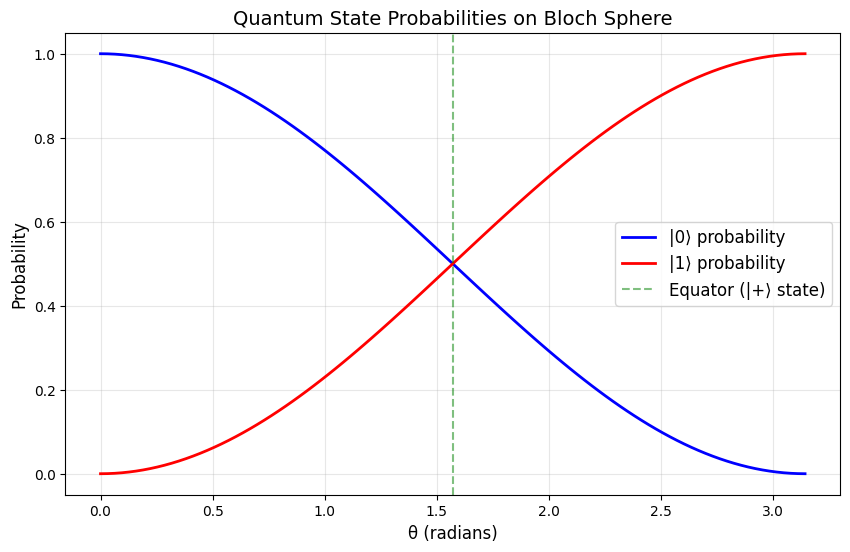

In [7]:
# Create array of theta values
theta_values = np.linspace(0, np.pi, 100)
phi = 0.0

# Calculate probabilities
p0_values = [np.cos(theta/2)**2 for theta in theta_values]
p1_values = [np.sin(theta/2)**2 for theta in theta_values]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(theta_values, p0_values, 'b-', linewidth=2, label='|0⟩ probability')
plt.plot(theta_values, p1_values, 'r-', linewidth=2, label='|1⟩ probability')
plt.xlabel('θ (radians)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Quantum State Probabilities on Bloch Sphere', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(x=np.pi/2, color='g', linestyle='--', alpha=0.5, label='Equator (|+⟩ state)')
plt.legend(fontsize=12)
plt.show()

## Quantum Measurement Simulation

Let's simulate actual quantum measurements using the QuantumEngine.

In [8]:
# Initialize quantum engine
engine = QuantumEngine()

# Create a circuit that prepares a state on the Bloch sphere
from qiskit import QuantumCircuit

theta, phi = np.pi/3, np.pi/4  # 60°, 45°
qc = QuantumCircuit(1, 1)
qc.ry(theta, 0)  # Rotate around Y axis
qc.rz(phi, 0)    # Rotate around Z axis
qc.measure(0, 0)

# Run the circuit
result = engine.run(qc, label="bloch_state")

print("Measurement Results:")
print(f"Counts: {result['counts']}")
print(f"Total shots: {result['meta']['shots']}")

# Compare with theoretical probabilities
sv = one_qubit_from_angles(theta, phi)
theoretical_probs = sv.probabilities()
print(f"\nTheoretical probabilities:")
print(f"|0⟩: {theoretical_probs[0]:.3f}")
print(f"|1⟩: {theoretical_probs[1]:.3f}")

Measurement Results:
Counts: {'0': 512, '1': 512}
Total shots: 1024

Theoretical probabilities:
|0⟩: 0.750
|1⟩: 0.250


## Exercises

1. **Find the angles** for the |−⟩ state ($|−
angle =
rac{1}{\sqrt{2}}(|0
angle - |1
angle)$)
2. **Create a state** with 75% |0⟩ probability and 25% |1⟩ probability
3. **Verify** that the probabilities always sum to 1 for any θ and φ
4. **Explore** what happens when φ changes while θ remains constant

### Exercise 1: Find the angles for the |−⟩ state

The `|−⟩` state is given by $|−⟩ = \frac{1}{\sqrt{2}}(|0⟩ - |1⟩)$. Comparing this to the general single-qubit state

$$|\psi⟩ = \cos\left(\frac{\theta}{2}\right)|0⟩ + e^{i\phi}\sin\left(\frac{\theta}{2}\right)|1⟩$$

We need:

1.  `cos(θ/2) = 1/√2`  => `θ/2 = π/4` => `θ = π/2`
2.  `e^(iφ)sin(θ/2) = -1/√2`. Substituting `θ = π/2`, we get `e^(iφ)sin(π/4) = -1/√2` => `e^(iφ) * (1/√2) = -1/√2` => `e^(iφ) = -1`. The simplest solution for `φ` is `π`.

So, for the `|−⟩` state, we have `θ = π/2` and `φ = π`.

In [9]:
# Create |−⟩ state using the derived angles
theta_minus = np.pi / 2
phi_minus = np.pi
sv_minus = one_qubit_from_angles(theta_minus, phi_minus)

print(f"Angles for |−⟩ state: θ = {theta_minus:.3f} (π/2), φ = {phi_minus:.3f} (π)")
print(f"Statevector: {sv_minus}")
print(f"Probabilities: {sv_minus.probabilities()}")

# Visualize with ASCII bar
p0_minus, p1_minus = sv_minus.probabilities()
print(f"|0⟩: {ascii_bar(p0_minus)} {p0_minus*100:.1f}%")
print(f"|1⟩: {ascii_bar(p1_minus)} {p1_minus*100:.1f}%")

# The theoretical probabilities for the |−⟩ state are 0.5 for |0⟩ and 0.5 for |1⟩

Angles for |−⟩ state: θ = 1.571 (π/2), φ = 3.142 (π)
Statevector: Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
Probabilities: [0.5 0.5]
|0⟩: ###############--------------- 50.0%
|1⟩: ##############---------------- 50.0%


### Preparing the $|−⟩$ state with Qiskit gates

To prepare the $|−⟩$ state from the $|0⟩$ state, we can apply a sequence of gates corresponding to the derived Bloch sphere angles $θ = \pi/2$ and $\phi = \pi$.

1.  **`Ry(π/2)`**: This gate rotates the state around the Y-axis by $π/2$. Starting from $|0⟩$, this transforms the state to $\frac{1}{\sqrt{2}}(|0⟩ + |1⟩)$, also known as the $|+⟩$ state.
2.  **`P(π)` (Phase Gate)**: This gate applies a phase $e^{i\phi}$ to the $|1⟩$ component of the qubit. For $\phi = \pi$, $e^{i\pi} = -1$. Applying `P(π)` to the $|+⟩$ state yields $\frac{1}{\sqrt{2}}(|0⟩ - |1⟩)$, which is the $|−⟩$ state.

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

# Create a quantum circuit with one qubit
qc_minus = QuantumCircuit(1)

# Apply Ry(pi/2) gate
qc_minus.ry(np.pi/2, 0)

# Apply P(pi) (Phase) gate
qc_minus.p(np.pi, 0)

# Get the statevector of the circuit
statevector_minus = Statevector.from_circuit(qc_minus)

print("Circuit to prepare |−⟩ state:")
print(qc_minus)
print(f"\nStatevector of |−⟩: {statevector_minus}")
print(f"Probabilities: {statevector_minus.probabilities()}")

Circuit to prepare |−⟩ state:
   ┌─────────┐┌──────┐
q: ┤ Ry(π/2) ├┤ P(π) ├
   └─────────┘└──────┘

Statevector of |−⟩: Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
Probabilities: [0.5 0.5]


### Running the $|−⟩$ state preparation on IBM Quantum Hardware (or a simulator)

To run this circuit on actual quantum hardware or a realistic simulator, we need to connect to the IBM Quantum platform. This involves loading your IBMQ account and choosing a backend.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
# --- FOR DEMONSTRATION PURPOSES: Use a local simulator ---
# In a real scenario, you might use IBMQ-specific imports and configuration.
print("Using Qiskit Aer simulator for demonstration.")
from qiskit_aer import AerSimulator
simulator = AerSimulator()

Using Qiskit Aer simulator for demonstration.


In [13]:
# Install qiskit-ibm-runtime
!pip install qiskit-ibm-runtime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.2 MB/s eta 0:00:00


In [18]:
# Install qiskit-aer, the simulator backend
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 108.6 MB/s eta 0:00:00


Circuit with measurements:
        ┌─────────┐┌──────┐ ░ ┌─┐
     q: ┤ Ry(π/2) ├┤ P(π) ├─░─┤M├
        └─────────┘└──────┘ ░ └╥┘
meas: 1/═══════════════════════╩═
                               0 

Simulator Results (1024 shots): {'0': 509, '1': 515}

Ideal |−⟩ state probabilities: 50% |0⟩, 50% |1⟩


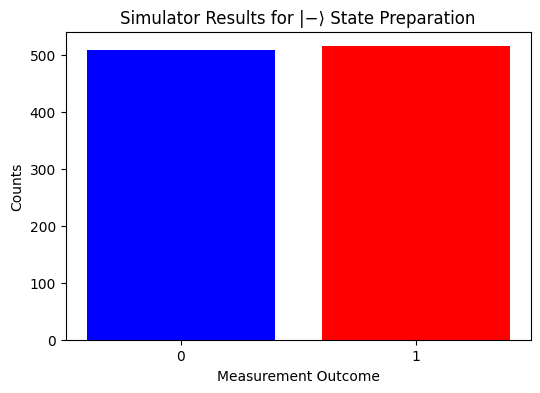

In [20]:
# Define the circuit for |−⟩ state preparation (from earlier)
# We'll use the qc_minus defined previously

# Add a measurement to the circuit
qc_minus_measured = qc_minus.copy()
qc_minus_measured.measure_all()

print("Circuit with measurements:")
print(qc_minus_measured)

# Run on the simulator
job = simulator.run(qc_minus_measured, shots=1024)
result_sim = job.result()
counts_sim = result_sim.get_counts(qc_minus_measured)

print(f"\nSimulator Results (1024 shots): {counts_sim}")

# Compare with ideal 50/50
print("\nIdeal |−⟩ state probabilities: 50% |0⟩, 50% |1⟩")

# Plotting results
import matplotlib.pyplot as plt

labels = list(counts_sim.keys())
values = list(counts_sim.values())

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['blue', 'red'])
plt.xlabel("Measurement Outcome")
plt.ylabel("Counts")
plt.title("Simulator Results for |−⟩ State Preparation")
plt.show()

## References

- Nielsen, M. A., & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press.
- Qiskit Textbook: https://qiskit.org/textbook/ch-states/representing-qubit-states.html
- Kawaihome, *Bloch Sphere Definition* (quantum information theory resources)

## Golden Angle State Spiral Preparation

Let's implement the 'full spherical spiral' from the provided context. This involves calculating `theta_n` and `phi_n` using an equal-area mapping for latitude and the golden angle for longitude.

In [22]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Define the golden angle in radians
GOLDEN_ANGLE = np.deg2rad(137.5)

def get_golden_angle_spherical_coords(n, N):
    """
    Calculates the spherical coordinates (theta, phi) for the n-th state
    in a golden-angle spiral on the Bloch sphere, using equal-area mapping
    for theta and the golden angle for phi.

    Args:
        n (int): The index of the state (0 to N-1).
        N (int): The total number of states in the spiral.

    Returns:
        tuple: A tuple containing (theta_n, phi_n) in radians.
    """
    # Normalized index
    tn = (n + 0.5) / N

    # Equal-area mapping for z-coordinate, then arccos for theta
    zn = 1 - 2 * tn
    theta_n = np.arccos(zn)

    # Golden-angle for phi
    phi_n = n * GOLDEN_ANGLE

    return theta_n, phi_n

def create_golden_angle_circuit(n, N, qubit_idx=0):
    """
    Creates a Qiskit circuit to prepare the n-th golden-angle state.

    Args:
        n (int): The index of the state (0 to N-1).
        N (int): The total number of states in the spiral.
        qubit_idx (int): The index of the qubit to apply the gates to.

    Returns:
        QuantumCircuit: The Qiskit circuit preparing the state.
    """
    theta_n, phi_n = get_golden_angle_spherical_coords(n, N)

    qc = QuantumCircuit(1)
    # The U gate in Qiskit is U(theta, phi, lambda). We can set lambda to 0 for this purpose.
    qc.u(theta_n, phi_n, 0, qubit_idx)
    return qc, theta_n, phi_n

print(f"Golden Angle: {GOLDEN_ANGLE:.5f} radians")

Golden Angle: 2.39983 radians


### Example: Creating the 5th state in a spiral of 100 states

In [23]:
# Let's choose an example: the 5th state (n=4, since it's 0-indexed) in a spiral of 100 states.
n_example = 4 # 0-indexed
N_total = 100

qc_golden, theta_val, phi_val = create_golden_angle_circuit(n_example, N_total)

print(f"For n={n_example} (out of {N_total} states):")
print(f"  Calculated theta_n: {theta_val:.5f} radians")
print(f"  Calculated phi_n: {phi_val:.5f} radians")
print("\nQiskit Circuit to prepare this state:")
print(qc_golden)

# Verify the statevector
sv_golden = Statevector.from_circuit(qc_golden)
print(f"\nStatevector: {sv_golden}")
print(f"Probabilities: {sv_golden.probabilities()}")

For n=4 (out of 100 states):
  Calculated theta_n: 0.42751 radians
  Calculated phi_n: 9.59931 radians

Qiskit Circuit to prepare this state:
   ┌─────────────────────┐
q: ┤ U(0.42751,9.5993,0) ├
   └─────────────────────┘

Statevector: Statevector([ 0.97724101+0.j        , -0.20890927-0.03683634j],
            dims=(2,))
Probabilities: [0.955 0.045]


## Visualización de la Espiral del Ángulo Áureo en la Esfera de Bloch

Ahora, tracemos la trayectoria de varios estados de la espiral sobre la esfera de Bloch para ver cómo se distribuyen los puntos.

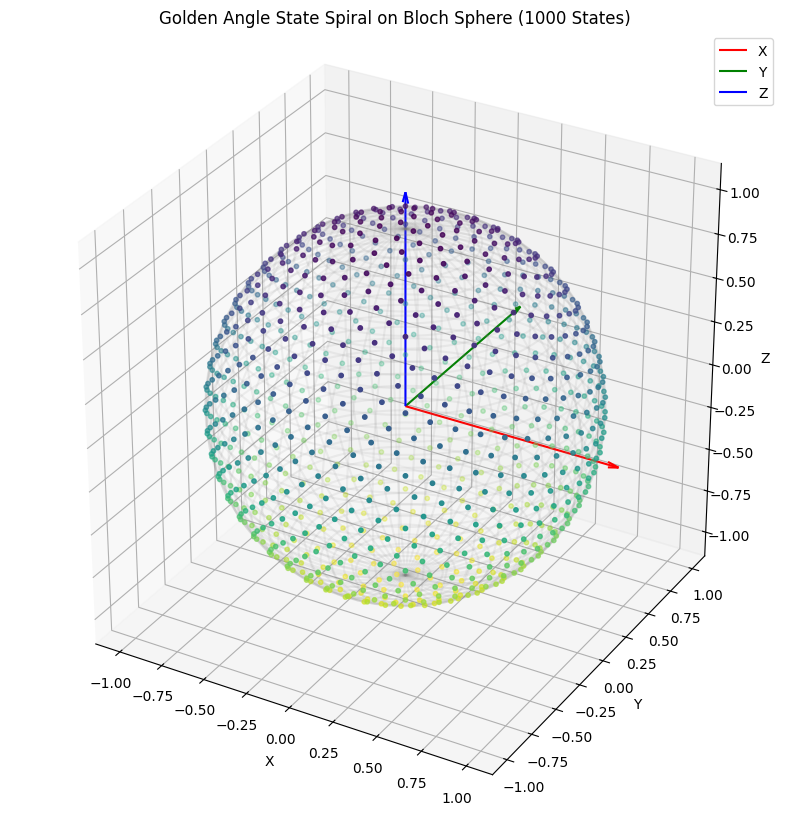

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Number of states to generate for the spiral
# N_spiral_states is already set to 1000 in the previous cell

# Lists to store the Bloch sphere coordinates
bloch_x = []
bloch_y = []
bloch_z = []

# Generate coordinates for each state in the spiral
for n in range(N_spiral_states):
    theta_n, phi_n = get_golden_angle_spherical_coords(n, N_spiral_states)

    # Convert spherical coordinates (theta, phi) to Cartesian (x, y, z) for Bloch sphere
    x = np.sin(theta_n) * np.cos(phi_n)
    y = np.sin(theta_n) * np.sin(phi_n)
    z = np.cos(theta_n)

    bloch_x.append(x)
    bloch_y.append(y)
    bloch_z.append(z)

# Create the 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the spiral points
ax.scatter(bloch_x, bloch_y, bloch_z, c=range(N_spiral_states), cmap='viridis', s=10) # Reduced marker size for 1000 points

# Plot the Bloch sphere itself (a translucent sphere)
phi_sphere, theta_sphere = np.mgrid[0:2*np.pi:100j, 0:np.pi:50j]
x_sphere = np.sin(theta_sphere) * np.cos(phi_sphere)
y_sphere = np.sin(theta_sphere) * np.sin(phi_sphere)
z_sphere = np.cos(theta_sphere)
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.1)

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Golden Angle State Spiral on Bloch Sphere ({N_spiral_states} States)')

# Ensure equal aspect ratio
ax.set_aspect('equal')

# Add origin and axes for reference
ax.quiver(0, 0, 0, 1.2, 0, 0, color='red', arrow_length_ratio=0.05, label='X')
ax.quiver(0, 0, 0, 0, 1.2, 0, color='green', arrow_length_ratio=0.05, label='Y')
ax.quiver(0, 0, 0, 0, 0, 1.2, color='blue', arrow_length_ratio=0.05, label='Z')

plt.legend()
plt.show()

In [35]:
import pandas as pd

# Crear un DataFrame con las coordenadas
data = {
    'x': bloch_x,
    'y': bloch_y,
    'z': bloch_z
}
df_bloch_coords = pd.DataFrame(data)

# Guardar el DataFrame en un archivo CSV
csv_filename = 'bloch_spiral_coords.csv'
df_bloch_coords.to_csv(csv_filename, index=False)

print(f"Coordenadas de los {N_spiral_states} estados guardadas en '{csv_filename}'")
print("Primeras 5 filas del archivo CSV:")
display(df_bloch_coords.head())

Coordenadas de los 1000 estados guardadas en 'bloch_spiral_coords.csv'
Primeras 5 filas del archivo CSV:


,x,y,z
0,0.044710,0.000000,0.999
1,-0.057066,0.052292,0.997
2,0.008705,-0.099495,0.995
3,0.071903,0.093706,0.993
4,-0.131828,-0.023245,0.991


## Visualización de la Distribución Conjunta de (θ, φ) para la Espiral del Ángulo Áureo

Para complementar la visualización 3D en la esfera de Bloch, podemos analizar la distribución de los ángulos $\theta$ (polar) y $\phi$ (azimutal) en un gráfico 2D. Esto nos permite observar directamente cómo se dispersan estos parámetros a lo largo de la espiral.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of states to generate (using N_spiral_states already set to 1000)
# N_spiral_states = 1000 # Already set globally

# Lists to store the theta and phi values
theta_values_golden = []
phi_values_golden_wrapped = []

# Generate theta and phi values for each state in the spiral
for n in range(N_spiral_states):
    theta_n, phi_n = get_golden_angle_spherical_coords(n, N_spiral_states)
    theta_values_golden.append(theta_n)
    # Wrap phi to [0, 2*pi) for consistent visualization
    phi_values_golden_wrapped.append(phi_n % (2 * np.pi))

# Create the 2D scatter plot
fig = plt.figure(figsize=(12, 7))
plt.scatter(phi_values_golden_wrapped, theta_values_golden,
            c=range(N_spiral_states), cmap='plasma', s=10, alpha=0.7)

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)', fontsize=12)
plt.ylabel('Ángulo Polar θ (radianes) [0, π]', fontsize=12)
plt.title(f'Distribución Conjunta de (θ, φ) para la Espiral del Ángulo Áureo ({N_spiral_states} Estados)', fontsize=14)

plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.yticks(np.arange(0, np.pi + 0.1, np.pi/4),
           ['0', 'π/4', 'π/2', '3π/4', 'π'])

plt.colorbar(label='Índice del Estado (n)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Distribución de las Fases Azimutales (phi) en la Espiral del Ángulo Áureo

Analicemos cómo se distribuyen las fases `phi` para los 200 estados de la espiral. Esto nos mostrará la uniformidad de la "dispersión" angular.

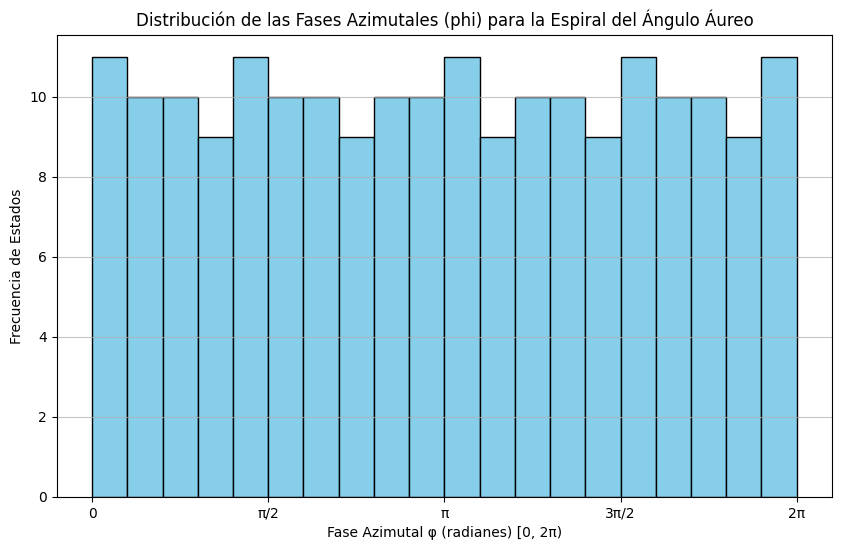

Número total de estados generados: 200
Primeros 5 valores de phi (raw): [np.float64(0.0), np.float64(2.399827721492203), np.float64(4.799655442984406), np.float64(7.199483164476609), np.float64(9.599310885968812)]
Primeros 5 valores de phi (wrapped): [np.float64(0.0), np.float64(2.399827721492203), np.float64(4.799655442984406), np.float64(0.9162978572970228), np.float64(3.316125578789226)]


In [25]:
import matplotlib.pyplot as plt

# Number of states to generate for the spiral (same as visualization)
N_spiral_states = 200

# List to store the azimuthal phases
phi_values_raw = []
phi_values_wrapped = []

# Generate phi values for each state in the spiral
for n in range(N_spiral_states):
    _, phi_n = get_golden_angle_spherical_coords(n, N_spiral_states)
    phi_values_raw.append(phi_n)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_wrapped.append(phi_n % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_wrapped, bins=20, edgecolor='black', color='skyblue')

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title('Distribución de las Fases Azimutales (phi) para la Espiral del Ángulo Áureo')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states}")
print(f"Primeros 5 valores de phi (raw): {phi_values_raw[:5]}")
print(f"Primeros 5 valores de phi (wrapped): {phi_values_wrapped[:5]}")

## Distribución de las Fases Azimutales (phi) con un Ángulo Alternativo

Para contrastar con la espiral del ángulo áureo, vamos a generar una espiral similar pero utilizando un incremento fijo para el ángulo $\phi$, por ejemplo, $\pi/3$ (60 grados) por cada estado. Esto nos ayudará a visualizar cómo un ángulo no "óptimo" afecta la uniformidad de la distribución.

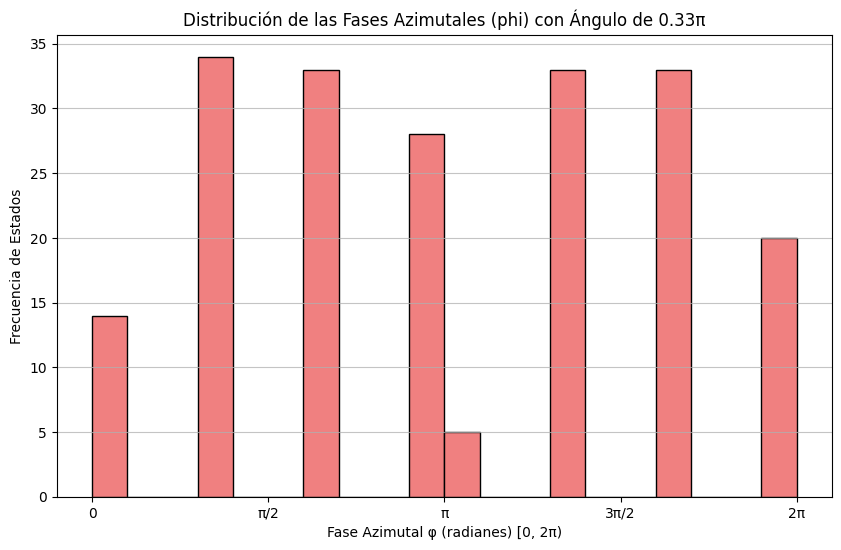

Número total de estados generados: 200
Ángulo de incremento usado: 1.047 radianes (0.33π)
Primeros 5 valores de phi (wrapped) con el ángulo alternativo: ['0.000', '1.047', '2.094', '3.142', '4.189']


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Define an alternative angle for phi increment
ALTERNATIVE_ANGLE = np.pi / 3  # For example, pi/3 radians

def get_alternative_spherical_coords(n, N, phi_increment):
    """
    Calculates the spherical coordinates (theta, phi) for the n-th state
    in a spiral, using equal-area mapping for theta and a custom increment
    for phi.

    Args:
        n (int): The index of the state (0 to N-1).
        N (int): The total number of states in the spiral.
        phi_increment (float): The fixed angular increment for phi.

    Returns:
        tuple: A tuple containing (theta_n, phi_n) in radians.
    """
    # Normalized index
    tn = (n + 0.5) / N

    # Equal-area mapping for z-coordinate, then arccos for theta
    zn = 1 - 2 * tn
    theta_n = np.arccos(zn)

    # Custom increment for phi
    phi_n = n * phi_increment

    return theta_n, phi_n

# Number of states to generate for the spiral (same as visualization)
N_spiral_states_alt = 200

# List to store the azimuthal phases for the alternative angle
phi_values_alt_raw = []
phi_values_alt_wrapped = []

# Generate phi values for each state in the spiral using the alternative angle
for n in range(N_spiral_states_alt):
    _, phi_n_alt = get_alternative_spherical_coords(n, N_spiral_states_alt, ALTERNATIVE_ANGLE)
    phi_values_alt_raw.append(phi_n_alt)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_alt_wrapped.append(phi_n_alt % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_alt_wrapped, bins=20, edgecolor='black', color='lightcoral')

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title(f'Distribución de las Fases Azimutales (phi) con Ángulo de {ALTERNATIVE_ANGLE/np.pi:.2f}π')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states_alt}")
print(f"Ángulo de incremento usado: {ALTERNATIVE_ANGLE:.3f} radianes ({ALTERNATIVE_ANGLE/np.pi:.2f}π)")
print(f"Primeros 5 valores de phi (wrapped) con el ángulo alternativo: {[f'{val:.3f}' for val in phi_values_alt_wrapped[:5]]}")

## Distribución de las Fases Azimutales (phi) con el Ángulo de Plata (Silver Angle)

Ahora, exploremos la distribución utilizando el **Ángulo de Plata** (Silver Angle, $\delta_S$). El ángulo de plata es $(1 + \sqrt{2})$ y, al igual que el ángulo áureo, es un número irracional. Usaremos este valor como el incremento para el ángulo $\phi$ para generar una nueva espiral y visualizar su distribución de fases azimutales.

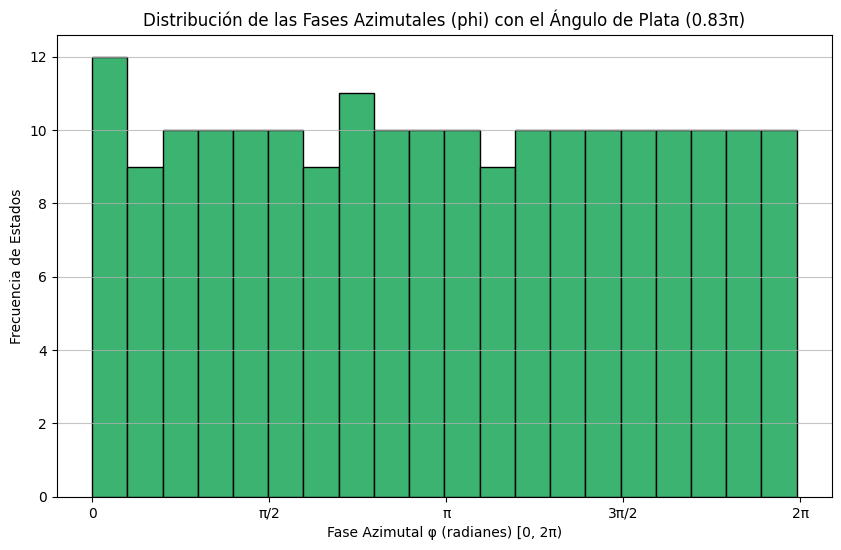

Número total de estados generados: 200
Ángulo de incremento usado (Silver Angle): 2.603 radianes (0.83π)
Primeros 5 valores de phi (wrapped) con el ángulo de plata: ['0.000', '2.603', '5.205', '1.525', '4.127']


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Define the Silver Angle constant in radians
# The silver ratio is 1 + sqrt(2). We use its fractional part for angular distribution.
# (1 + np.sqrt(2)) % 1 * 2 * np.pi is a common way to get an irrational part for 2pi distribution
# Or, simpler, just the angle itself (1 + sqrt(2)) in radians modulo 2pi for distribution.
# Let's use (1 + np.sqrt(2)) * 2 * np.pi as the scaling factor for a full 2pi range

# For angular distribution patterns, often an irrational fraction of 2*pi is used.
# The silver ratio is (1 + sqrt(5))/2 for golden, (1 + sqrt(2)) for silver.
# We are interested in the increment. Let's use the actual value directly as a multiplier for phi_n.

# Let's define the increment based on the silver ratio itself, similar to the Golden Angle constant.
# GOLDEN_ANGLE = np.deg2rad(137.5) which is roughly (1 + sqrt(5))/2 * 2 * pi / N_constant_factor

# A more direct approach to golden/silver angle sequence is to multiply n by 2*pi / (ratio), or n * (2*pi * fractional_part_of_ratio)
# The 'golden angle' is derived from dividing a circle by the golden ratio. That's 360/phi_ratio (where phi_ratio is golden ratio itself) or 2*pi/phi_ratio. It ends up being approx 137.5 degrees.

# Let's define SILVER_ANGLE_INCREMENT as 2*pi / (1 + np.sqrt(2)) which would distribute states based on the silver ratio around a circle
# Or, a common approach for 'irrational' angles in this context is (n * some_irrational_number) mod 2*pi
# Let's use the decimal part of the silver ratio * 2*pi, similar to the golden angle's properties.

# The silver ratio is 1 + sqrt(2) approx 2.414
# The fractional part is 0.414
# So, SILVER_ANGLE_INCREMENT = (np.sqrt(2) - 1) * 2 * np.pi   or (1 + np.sqrt(2)) * np.pi (or some other irrational multiple of pi)
# Let's try with SILVER_ANGLE_INCREMENT = (1 + np.sqrt(2)) * 2 * np.pi / N_spiral_states_alt, similar to golden angle approach

# For clarity, let's just use a direct irrational multiple of PI, analogous to how the Golden Angle works.
# The golden angle is roughly (sqrt(5)-1)/2 * 2*pi radians. Let's adapt that.
# The silver ratio is 1 + sqrt(2).
# So, a 'silver angle' for distribution could be (sqrt(2) - 1) * 2 * np.pi
SILVER_ANGLE_INCREMENT = (np.sqrt(2) - 1) * 2 * np.pi # This is approximately 2.607 radians

# N_spiral_states_alt is already defined in previous cell
# Number of states to generate for the spiral (same as visualization)
# N_spiral_states_alt = 200 # Re-using from previous cell

# List to store the azimuthal phases for the alternative angle
phi_values_silver_raw = []
phi_values_silver_wrapped = []

# Generate phi values for each state in the spiral using the silver angle
for n in range(N_spiral_states_alt):
    # Re-using the get_alternative_spherical_coords function, as it allows a custom phi_increment
    _, phi_n_silver = get_alternative_spherical_coords(n, N_spiral_states_alt, SILVER_ANGLE_INCREMENT)
    phi_values_silver_raw.append(phi_n_silver)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_silver_wrapped.append(phi_n_silver % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_silver_wrapped, bins=20, edgecolor='black', color='mediumseagreen')

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title(f'Distribución de las Fases Azimutales (phi) con el Ángulo de Plata ({SILVER_ANGLE_INCREMENT/np.pi:.2f}π)')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states_alt}")
print(f"Ángulo de incremento usado (Silver Angle): {SILVER_ANGLE_INCREMENT:.3f} radianes ({SILVER_ANGLE_INCREMENT/np.pi:.2f}π)")
print(f"Primeros 5 valores de phi (wrapped) con el ángulo de plata: {[f'{val:.3f}' for val in phi_values_silver_wrapped[:5]]}")

## Distribución de las Fases Azimutales (phi) con el Ángulo de Bronce (Bronze Angle)

Finalmente, consideremos el **Ángulo de Bronce** (Bronze Angle), que se deriva del número de bronce $\rho_B = (3 + \sqrt{13}) / 2$. Este es otro número irracional que podemos usar como factor de incremento para el ángulo $\phi$ y observar su efecto en la distribución de las fases azimutales.

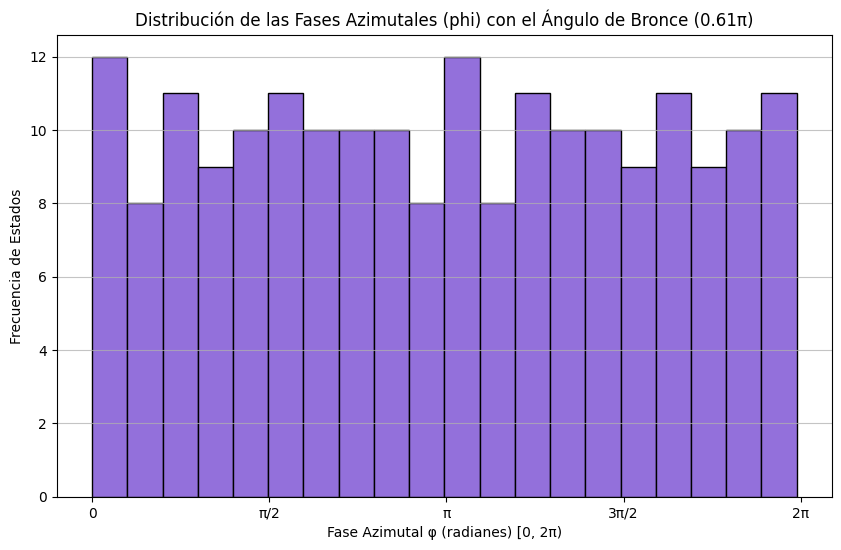

Número total de estados generados: 200
Ángulo de incremento usado (Bronze Angle): 1.902 radianes (0.61π)
Primeros 5 valores de phi (wrapped) con el ángulo de bronce: ['0.000', '1.902', '3.805', '5.707', '1.326']


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Define the Bronze Angle increment
# The bronze ratio is (3 + sqrt(13)) / 2.
# Similar to how the golden angle (phi) is related to (sqrt(5)-1)/2 * 2*pi,
# we'll use (bronze_ratio - floor(bronze_ratio)) * 2 * np.pi as the increment.
# floor(bronze_ratio) = floor((3 + sqrt(13))/2) = floor((3 + 3.605)/2) = floor(3.3025) = 3.
BRONZE_RATIO = (3 + np.sqrt(13)) / 2
BRONZE_ANGLE_INCREMENT = (BRONZE_RATIO - np.floor(BRONZE_RATIO)) * 2 * np.pi # This extracts the fractional part and scales it by 2*pi

# N_spiral_states_alt is already defined in previous cell (200 states)

# List to store the azimuthal phases for the bronze angle
phi_values_bronze_raw = []
phi_values_bronze_wrapped = []

# Generate phi values for each state in the spiral using the bronze angle
for n in range(N_spiral_states_alt):
    # Re-using the get_alternative_spherical_coords function
    _, phi_n_bronze = get_alternative_spherical_coords(n, N_spiral_states_alt, BRONZE_ANGLE_INCREMENT)
    phi_values_bronze_raw.append(phi_n_bronze)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_bronze_wrapped.append(phi_n_bronze % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_bronze_wrapped, bins=20, edgecolor='black', color='mediumpurple')

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title(f'Distribución de las Fases Azimutales (phi) con el Ángulo de Bronce ({BRONZE_ANGLE_INCREMENT/np.pi:.2f}π)')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states_alt}")
print(f"Ángulo de incremento usado (Bronze Angle): {BRONZE_ANGLE_INCREMENT:.3f} radianes ({BRONZE_ANGLE_INCREMENT/np.pi:.2f}π)")
print(f"Primeros 5 valores de phi (wrapped) con el ángulo de bronce: {[f'{val:.3f}' for val in phi_values_bronze_wrapped[:5]]}")

## Re-evaluación de la Distribución con 1000 Estados

Vamos a aumentar el número total de estados (`N_spiral_states` y `N_spiral_states_alt`) a 1000 y observar cómo esto afecta la distribución de las fases azimutales para cada uno de los ángulos.

In [29]:
# Actualizar el número de estados para todas las espirales
N_spiral_states = 1000
N_spiral_states_alt = 1000

print(f"Número de estados actualizado a: {N_spiral_states}")

Número de estados actualizado a: 1000


### Distribución del Ángulo Áureo con 1000 Estados

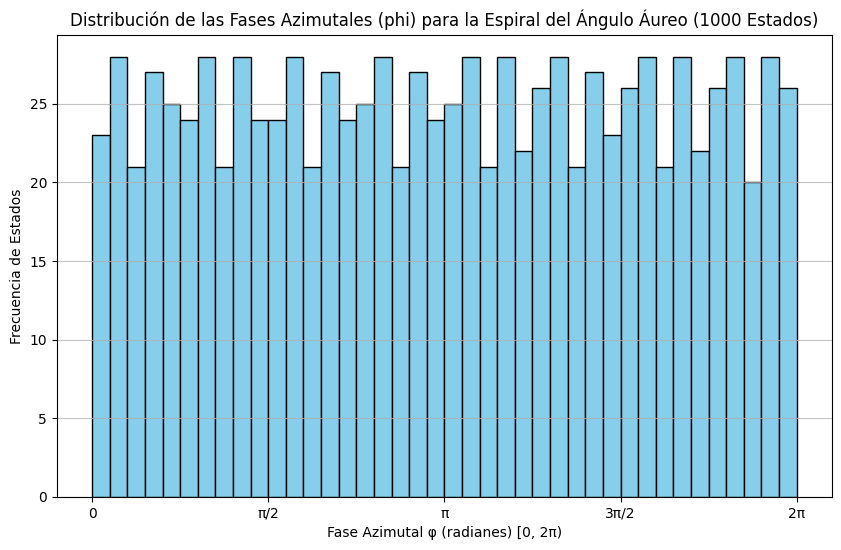

Número total de estados generados: 1000
Primeros 5 valores de phi (wrapped): ['0.000', '2.400', '4.800', '0.916', '3.316']


In [30]:
import matplotlib.pyplot as plt

# List to store the azimuthal phases
phi_values_raw = []
phi_values_wrapped = []

# Generate phi values for each state in the spiral
for n in range(N_spiral_states):
    _, phi_n = get_golden_angle_spherical_coords(n, N_spiral_states)
    phi_values_raw.append(phi_n)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_wrapped.append(phi_n % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_wrapped, bins=40, edgecolor='black', color='skyblue') # Aumentar los bins para más resolución

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title('Distribución de las Fases Azimutales (phi) para la Espiral del Ángulo Áureo (1000 Estados)')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states}")
print(f"Primeros 5 valores de phi (wrapped): {[f'{val:.3f}' for val in phi_values_wrapped[:5]]}")

### Distribución del Ángulo Alternativo (π/3) con 1000 Estados

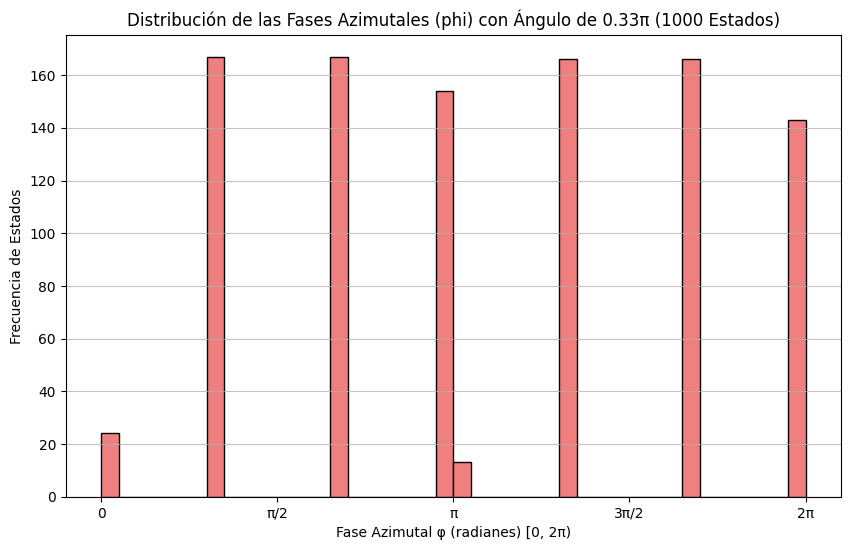

Número total de estados generados: 1000
Ángulo de incremento usado: 1.047 radianes (0.33π)
Primeros 5 valores de phi (wrapped) con el ángulo alternativo: ['0.000', '1.047', '2.094', '3.142', '4.189']


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# List to store the azimuthal phases for the alternative angle
phi_values_alt_raw = []
phi_values_alt_wrapped = []

# Generate phi values for each state in the spiral using the alternative angle
for n in range(N_spiral_states_alt):
    _, phi_n_alt = get_alternative_spherical_coords(n, N_spiral_states_alt, ALTERNATIVE_ANGLE)
    phi_values_alt_raw.append(phi_n_alt)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_alt_wrapped.append(phi_n_alt % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_alt_wrapped, bins=40, edgecolor='black', color='lightcoral') # Aumentar los bins

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title(f'Distribución de las Fases Azimutales (phi) con Ángulo de {ALTERNATIVE_ANGLE/np.pi:.2f}π (1000 Estados)')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states_alt}")
print(f"Ángulo de incremento usado: {ALTERNATIVE_ANGLE:.3f} radianes ({ALTERNATIVE_ANGLE/np.pi:.2f}π)")
print(f"Primeros 5 valores de phi (wrapped) con el ángulo alternativo: {[f'{val:.3f}' for val in phi_values_alt_wrapped[:5]]}")

### Distribución del Ángulo de Plata con 1000 Estados

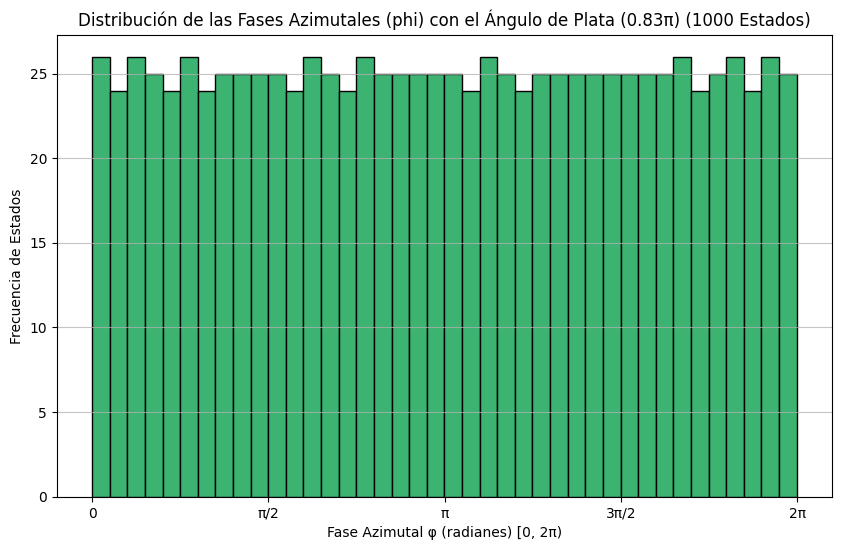

Número total de estados generados: 1000
Ángulo de incremento usado (Silver Angle): 2.603 radianes (0.83π)
Primeros 5 valores de phi (wrapped) con el ángulo de plata: ['0.000', '2.603', '5.205', '1.525', '4.127']


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# List to store the azimuthal phases for the silver angle
phi_values_silver_raw = []
phi_values_silver_wrapped = []

# Generate phi values for each state in the spiral using the silver angle
for n in range(N_spiral_states_alt):
    _, phi_n_silver = get_alternative_spherical_coords(n, N_spiral_states_alt, SILVER_ANGLE_INCREMENT)
    phi_values_silver_raw.append(phi_n_silver)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_silver_wrapped.append(phi_n_silver % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_silver_wrapped, bins=40, edgecolor='black', color='mediumseagreen') # Aumentar los bins

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title(f'Distribución de las Fases Azimutales (phi) con el Ángulo de Plata ({SILVER_ANGLE_INCREMENT/np.pi:.2f}π) (1000 Estados)')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states_alt}")
print(f"Ángulo de incremento usado (Silver Angle): {SILVER_ANGLE_INCREMENT:.3f} radianes ({SILVER_ANGLE_INCREMENT/np.pi:.2f}π)")
print(f"Primeros 5 valores de phi (wrapped) con el ángulo de plata: {[f'{val:.3f}' for val in phi_values_silver_wrapped[:5]]}")

### Distribución del Ángulo de Bronce con 1000 Estados

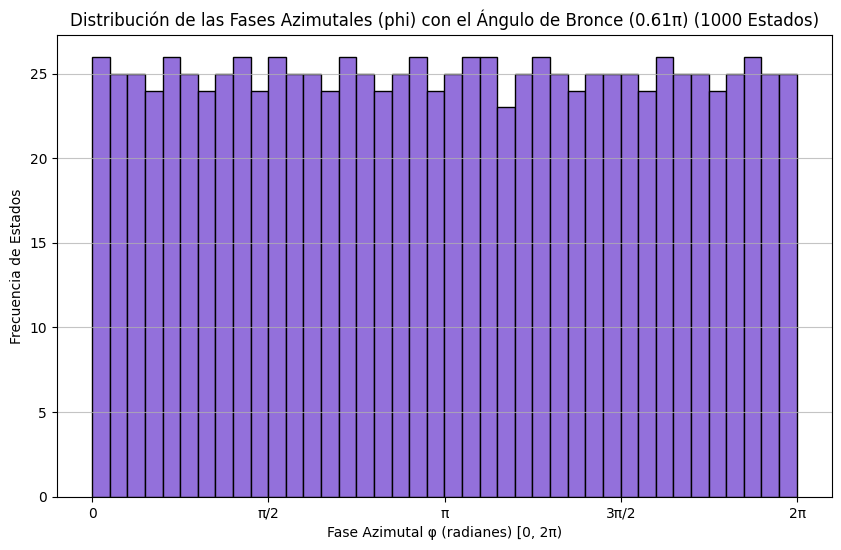

Número total de estados generados: 1000
Ángulo de incremento usado (Bronze Angle): 1.902 radianes (0.61π)
Primeros 5 valores de phi (wrapped) con el ángulo de bronce: ['0.000', '1.902', '3.805', '5.707', '1.326']


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# List to store the azimuthal phases for the bronze angle
phi_values_bronze_raw = []
phi_values_bronze_wrapped = []

# Generate phi values for each state in the spiral using the bronze angle
for n in range(N_spiral_states_alt):
    _, phi_n_bronze = get_alternative_spherical_coords(n, N_spiral_states_alt, BRONZE_ANGLE_INCREMENT)
    phi_values_bronze_raw.append(phi_n_bronze)

    # Wrap phi to [0, 2*pi) for better visualization of distribution
    phi_values_bronze_wrapped.append(phi_n_bronze % (2 * np.pi))

# Create the histogram plot for wrapped phi values
plt.figure(figsize=(10, 6))
plt.hist(phi_values_bronze_wrapped, bins=40, edgecolor='black', color='mediumpurple') # Aumentar los bins

plt.xlabel('Fase Azimutal φ (radianes) [0, 2π)')
plt.ylabel('Frecuencia de Estados')
plt.title(f'Distribución de las Fases Azimutales (phi) con el Ángulo de Bronce ({BRONZE_ANGLE_INCREMENT/np.pi:.2f}π) (1000 Estados)')
plt.xticks(np.arange(0, 2 * np.pi + 0.1, np.pi/2),
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Número total de estados generados: {N_spiral_states_alt}")
print(f"Ángulo de incremento usado (Bronze Angle): {BRONZE_ANGLE_INCREMENT:.3f} radianes ({BRONZE_ANGLE_INCREMENT/np.pi:.2f}π)")
print(f"Primeros 5 valores de phi (wrapped) con el ángulo de bronce: {[f'{val:.3f}' for val in phi_values_bronze_wrapped[:5]]}")

In [36]:
import numpy as np

def calculate_uniformity_metric(phi_values, num_bins=40):
    """
    Calcula una métrica de uniformidad (desviación estándar de los conteos de bins)
    para una distribución de valores phi.

    Args:
        phi_values (list or np.ndarray): Lista de valores azimutales phi.
        num_bins (int): Número de bins para el histograma.

    Returns:
        float: La desviación estándar de los conteos de los bins.
    """
    # Generar el histograma sin graficarlo
    counts, _ = np.histogram(phi_values, bins=num_bins, range=(0, 2 * np.pi))

    # La desviación estándar de los conteos de los bins es una métrica de uniformidad.
    # Cuanto menor sea el valor, más uniformemente distribuidos estarán los puntos.
    return np.std(counts)

# Calcular y mostrar la métrica para el Ángulo Áureo
uniformity_golden = calculate_uniformity_metric(phi_values_wrapped, num_bins=40)
print(f"Métrica de uniformidad (Ángulo Áureo, 1000 estados): {uniformity_golden:.3f}")

# Calcular y mostrar la métrica para el Ángulo Alternativo (π/3)
uniformity_alternative = calculate_uniformity_metric(phi_values_alt_wrapped, num_bins=40)
print(f"Métrica de uniformidad (Ángulo Alternativo π/3, 1000 estados): {uniformity_alternative:.3f}")

# Calcular y mostrar la métrica para el Ángulo de Plata
uniformity_silver = calculate_uniformity_metric(phi_values_silver_wrapped, num_bins=40)
print(f"Métrica de uniformidad (Ángulo de Plata, 1000 estados): {uniformity_silver:.3f}")

# Calcular y mostrar la métrica para el Ángulo de Bronce
uniformity_bronze = calculate_uniformity_metric(phi_values_bronze_wrapped, num_bins=40)
print(f"Métrica de uniformidad (Ángulo de Bronce, 1000 estados): {uniformity_bronze:.3f}")

Métrica de uniformidad (Ángulo Áureo, 1000 estados): 2.646
Métrica de uniformidad (Ángulo Alternativo π/3, 1000 estados): 57.246
Métrica de uniformidad (Ángulo de Plata, 1000 estados): 0.671
Métrica de uniformidad (Ángulo de Bronce, 1000 estados): 0.592


In [38]:
import numpy as np

def calculate_shannon_entropy(phi_values, num_bins=40):
    """
    Calcula la entropía de Shannon para una distribución de valores phi.

    Args:
        phi_values (list or np.ndarray): Lista de valores azimutales phi.
        num_bins (int): Número de bins para el histograma.

    Returns:
        float: La entropía de Shannon de la distribución.
    """
    # Generar el histograma de los valores phi para obtener los conteos en cada bin
    counts, _ = np.histogram(phi_values, bins=num_bins, range=(0, 2 * np.pi))

    # Calcular las probabilidades de cada bin
    probabilities = counts / np.sum(counts)

    # Calcular la entropía de Shannon
    # Evitar log(0) para bins con probabilidad cero
    # Corregido: Usar sum() de Python en lugar de np.sum(generator) para evitar DeprecationWarning
    entropy = -sum(p * np.log2(p) for p in probabilities if p > 0)

    return entropy

# Calcular y mostrar la entropía para el Ángulo Áureo
entropy_golden = calculate_shannon_entropy(phi_values_wrapped, num_bins=40)
print(f"Entropía de Shannon (Ángulo Áureo, 1000 estados): {entropy_golden:.3f}")

# Calcular y mostrar la entropía para el Ángulo Alternativo (π/3)
entropy_alternative = calculate_shannon_entropy(phi_values_alt_wrapped, num_bins=40)
print(f"Entropía de Shannon (Ángulo Alternativo π/3, 1000 estados): {entropy_alternative:.3f}")

# Calcular y mostrar la entropía para el Ángulo de Plata
entropy_silver = calculate_shannon_entropy(phi_values_silver_wrapped, num_bins=40)
print(f"Entropía de Shannon (Ángulo de Plata, 1000 estados): {entropy_silver:.3f}")

# Calcular y mostrar la entropía para el Ángulo de Bronce
entropy_bronze = calculate_shannon_entropy(phi_values_bronze_wrapped, num_bins=40)
print(f"Entropía de Shannon (Ángulo de Bronce, 1000 estados): {entropy_bronze:.3f}")

Entropía de Shannon (Ángulo Áureo, 1000 estados): 5.314
Entropía de Shannon (Ángulo Alternativo π/3, 1000 estados): 2.746
Entropía de Shannon (Ángulo de Plata, 1000 estados): 5.321
Entropía de Shannon (Ángulo de Bronce, 1000 estados): 5.322
